In [1]:
import sys

!{sys.executable} -m pip install transformers accelerate sentencepiece


  Using cached accelerate-1.14.0-py3-none-any.whl.metadata (19 kB)
   ---------------------------------------- 0.0/11.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.6 MB ? eta -:--:--
   - -------------------------------------- 0.5/11.6 MB 2.1 MB/s eta 0:00:06
   - -------------------------------------- 0.5/11.6 MB 2.1 MB/s eta 0:00:06
   -- ------------------------------------- 0.8/11.6 MB 1.4 MB/s eta 0:00:08
   --- ------------------------------------ 1.0/11.6 MB 1.3 MB/s eta 0:00:09
   ---- ----------------------------------- 1.3/11.6 MB 1.1 MB/s eta 0:00:10
   ---- ----------------------------------- 1.3/11.6 MB 1.1 MB/s eta 0:00:10
   ----- ---------------------------------- 1.6/11.6 MB 964.5 kB/s eta 0:00:11
   ----- ---------------------------------- 1.6/11.6 MB 964.5 kB/s eta 0:00:11
   ------ --------------------------------- 1.8/11.6 MB 940.7 kB/s eta 0:00:11
   ------ --------------------------------- 1.8/11.6 MB 940.7 kB/s eta 0:00:11
   ------- ----


[notice] A new release of pip is available: 26.1.1 -> 26.2
[notice] To update, run: C:\Users\Abhishek\Desktop\Document_Type_Project_Final\venv_easyocr\Scripts\python.exe -m pip install --upgrade pip


In [2]:
import torch
from PIL import Image
from transformers import BlipProcessor, BlipForConditionalGeneration

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

model_name = "Salesforce/blip-image-captioning-base"

processor = BlipProcessor.from_pretrained(model_name)
model = BlipForConditionalGeneration.from_pretrained(model_name).to(device)

print("BLIP loaded successfully")


C:\Users\Abhishek\Desktop\Document_Type_Project_Final\venv_easyocr\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Torch version: 2.11.0+cu128
CUDA available: True
Using device: cuda


Loading weights: 100%|████████████████████| 473/473 [00:00<00:00, 23574.71it/s]


BLIP loaded successfully


In [3]:
from pathlib import Path

dataset_path = Path(r"C:\Users\Abhishek\Desktop\Document_Type_Backup_Training_Files\dataset_raw")

print("Dataset folder exists:", dataset_path.exists())

for folder in dataset_path.iterdir():
    print(folder.name)

Dataset folder exists: True
Magazine
Newspaper
Novel
Printed_Letter
Report


In [4]:
newspaper_folder = Path(r"C:\Users\Abhishek\Desktop\Document_Type_Backup_Training_Files\dataset_raw\Newspaper")

print("Newspaper folder exists:", newspaper_folder.exists())

newspaper_images = list(newspaper_folder.glob("*.*"))

print("Total images:", len(newspaper_images))

for img in newspaper_images[:10]:
    print(img.name)
    

Newspaper folder exists: True
Total images: 270
0000644359.jpg
0000940821.jpg
001.jpg
0011927386.jpg
002.jpeg
003.JPG
004.jpg
005.jpg
006.png
00625137.jpg


In [5]:
image_path = newspaper_images[0]

print("Selected image:", image_path)
print("Exists:", image_path.exists())

Selected image: C:\Users\Abhishek\Desktop\Document_Type_Backup_Training_Files\dataset_raw\Newspaper\0000644359.jpg
Exists: True


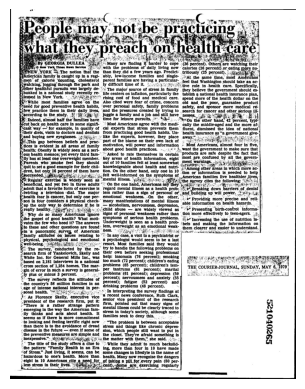

In [6]:
from PIL import Image
import matplotlib.pyplot as plt

image = Image.open(image_path).convert("RGB")

plt.imshow(image)
plt.axis("off")
plt.show()

In [7]:
import torch
from PIL import Image
from transformers import BlipProcessor, BlipForConditionalGeneration

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

model_name = "Salesforce/blip-image-captioning-base"

processor = BlipProcessor.from_pretrained(model_name)
model = BlipForConditionalGeneration.from_pretrained(model_name).to(device)

print("BLIP loaded successfully")

Torch version: 2.11.0+cu128
CUDA available: True
Using device: cuda


Loading weights: 100%|████████████████████| 473/473 [00:00<00:00, 28049.79it/s]


BLIP loaded successfully


In [8]:
inputs = processor(image, return_tensors="pt").to(device)

output = model.generate(
    **inputs,
    max_new_tokens=40
)

caption = processor.decode(output[0], skip_special_tokens=True)

print("Generated caption:")
print(caption)

Generated caption:
a newspaper article with a black and white image of a man in a suit


In [9]:
folders = ["Magazine", "Newspaper", "Novel", "Printed_Letter", "Report"]

for folder_name in folders:
    folder_path = dataset_path / folder_name
    image_files = list(folder_path.glob("*.*"))

    if not image_files:
        print(folder_name, "No images found")
        continue

    image_path = image_files[0]
    image = Image.open(image_path).convert("RGB")

    inputs = processor(image, return_tensors="pt").to(device)
    output = model.generate(**inputs, max_new_tokens=40)
    caption = processor.decode(output[0], skip_special_tokens=True)

    print("\n========================")
    print("Folder:", folder_name)
    print("Image:", image_path.name)
    print("Caption:", caption)


Folder: Magazine
Image: 1.jpg
Caption: shape magazine issue 5

Folder: Newspaper
Image: 0000644359.jpg
Caption: a newspaper article with a black and white image of a man in a suit

Folder: Novel
Image: +-+76361197_140.jpg
Caption: peter peter peter peter peter peter peter peter peter peter peter peter peter peter peter peter peter peter peter peter peter peter peter peter peter peter peter peter peter peter peter peter peter peter peter peter peter peter peter peter

Folder: Printed_Letter
Image: 00000831.jpg
Caption: a typed letter from the department of the department of the department of the department of the department of the department

Folder: Report
Image: 0000958516.jpg
Caption: a typed document from the first page of the paper
